In [1]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
import numpy as np


X = np.random.rand(100, 5)  
y = np.random.randint(0, 2, 100)  


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

In [3]:
fpr,tpr,thresholds = roc_curve(y_test, y_prob_rf)

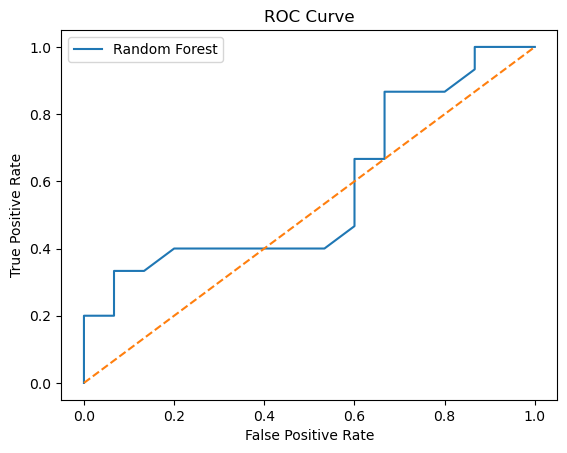

In [5]:
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

In [10]:
threshold = 0.4

y_pred_custom = (y_prob_rf >= threshold).astype(int)

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))

[[ 3 12]
 [ 2 13]]
              precision    recall  f1-score   support

           0       0.60      0.20      0.30        15
           1       0.52      0.87      0.65        15

    accuracy                           0.53        30
   macro avg       0.56      0.53      0.47        30
weighted avg       0.56      0.53      0.47        30



In [9]:
#Summary

#We evaluated the model using ROC curve and optimized the decision threshold.

#Lowering threshold increased recall and helped detect more churn-risk customers. After testing multiple thresholds, 0.4 provided the best balance between recall and false alarms.

#This supports proactive retention strategies while keeping operational costs manageable.